## Data loading and preprocessing

Load raw data and aggregate transactions to customer-day level for experiment design.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm

# Load raw transactional data
purchases = pd.read_csv("data/purchases.csv", parse_dates=['date'])
products = pd.read_csv("data/products.csv")

# Merge and compute transaction cost
# Aggregate to customer-day level
df = (
    purchases.merge(products, on='product_id', how='left')
    .assign(cost=lambda x: x['quantity'] * x['price'])
    .groupby(['InvoiceID','date','CustomerID'], as_index=False)['cost'].sum()
    .drop(columns='InvoiceID')
    .astype({'CustomerID':str})
)

# Data checks
df.info()
display(
    df.head(3),
    df.describe(percentiles=[0.25,0.5,0.75,0.99]),
    f'Max product unit price: {float(products.price.max())}',
    f'Duplicates: {int(df.duplicated().sum())}'
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33499 entries, 0 to 33498
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        33499 non-null  datetime64[ns]
 1   CustomerID  33499 non-null  object        
 2   cost        33499 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 785.3+ KB


,date,CustomerID,cost
0,2015-03-15,1000,29.19
1,2014-06-24,1000,18.30
2,2015-07-24,1000,26.10


,date,cost
count,33499,33499.000000
mean,2015-04-05 07:03:09.462372096,300.170496
min,2014-01-01 00:00:00,0.550000
25%,2014-12-11 00:00:00,24.150000
50%,2015-05-10 00:00:00,91.800000
75%,2015-09-14 00:00:00,331.420000
99%,2015-12-12 00:00:00,2717.625600
max,2015-12-30 00:00:00,168469.600000
std,NaN,1337.061109


'Max product unit price: 649.5'

'Duplicates: 41'

## Data cleaning and time alignment

Remove duplicates, align data to full weeks, and filter outliers.

In [17]:
# Remove duplicates
df.drop_duplicates(inplace=True, ignore_index=True)


# Align dataset to full calendar weeks
mn_date, mx_date = min(df.date), max(df.date)

first_monday = (
    mn_date + pd.offsets.Week(weekday=0, normalize=True),
    mn_date
)[mn_date.dayofweek == 0]

last_sunday = (
    mx_date - pd.offsets.Week(weekday=6, normalize=True),
    mx_date
)[mx_date.dayofweek == 6]

df_filtered = df[
    (df['date'] >= first_monday) &
    (df['date'] < (last_sunday + pd.Timedelta(days=1)))
].copy()


# Remove extreme invoice-level outliers identified during data exploration
# (max unit price ≈ 649, 99th percentile ≈ 2.7k, max invoice ≈ 168k).
q_001 = df_filtered['cost'].quantile(0.01)
q_099 = df_filtered['cost'].quantile(0.99)

df_filtered = df_filtered[
    (df_filtered['cost'] > q_001) &
    (df_filtered['cost'] < q_099)
]

display(df_filtered.head(3))


# Verify that the dataset contains full weeks only + how many full weeks in the dataset
mn, mx = df_filtered['date'].min(), df_filtered['date'].max()
total_days = (mx - mn).days + 1
full_weeks = total_days / 7

print(f'full weeks: {full_weeks}')


,date,CustomerID,cost
0,2015-03-15,1000,29.19
1,2014-06-24,1000,18.30
2,2015-07-24,1000,26.10


full weeks: 103.0


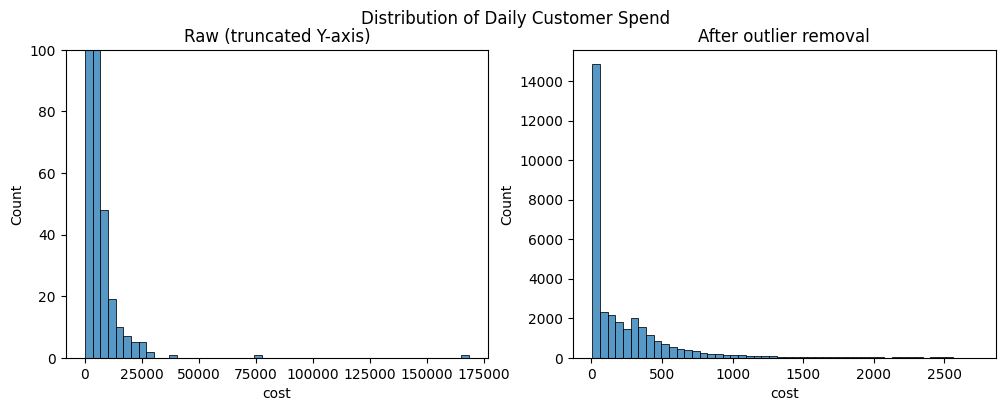

In [18]:
# outliers chart
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# raw
sns.histplot(df, x='cost', bins=50, ax=ax1)
ax1.set_ylim(0, 100)
ax1.set_title('Raw (truncated Y-axis)')

# filtered
sns.histplot(df_filtered, x='cost', bins=50, ax=ax2)
ax2.set_title('After outlier removal')

plt.suptitle('Distribution of Daily Customer Spend')
plt.show()

## CUPED covariate selection

Select pre-experiment window and validate correlation with target metric.

In [19]:
# Define pre-experiment window
window = 8

# metric for pre and pre-pre periods
pre_start = df_filtered['date'].max() - pd.Timedelta(weeks=window)
prepre_start = pre_start - pd.Timedelta(weeks=window)


pre = df_filtered[df_filtered['date'] >= pre_start].groupby('CustomerID')[['cost']].sum()
prepre = df_filtered[
    (df_filtered['date'] >= prepre_start) &
    (df_filtered['date'] < pre_start)
].groupby('CustomerID')[['cost']].sum()


combined = pre.merge(
    prepre,
    left_index=True,
    right_index=True,
    how='left',
    suffixes=['_pre', '_prepre']
).fillna(0)

# Evaluate correlation (covariate quality)
corr, pvalue = stats.pearsonr(combined['cost_pre'], combined['cost_prepre'])

print(f"pre-experimental covariate window: {window} weeks "
      f"(correlation = {corr:.2f}, "
      f"p-value = {pvalue:.2f})")

pre-experimental covariate window: 8 weeks (correlation = 0.78, p-value = 0.00)


## CUPED transformation

Estimate theta and construct variance reduced metric.

In [20]:
def get_theta(metric_pre, metric_exp):
    """
    Estimate CUPED coefficient (theta) as
    cov(pre-period, experiment-period) / var(pre-period)
    """
    return metric_pre.cov(metric_exp, ddof=1) / metric_pre.var(ddof=1)


def get_cuped(metric_pre, metric_exp, theta, mu_pre):
    """
    Construct CUPED-adjusted metric.
    """
    
    return metric_exp - theta * (metric_pre - mu_pre)


# Estimate CUPED coefficient (theta)
# Build CUPED-adjusted metric
theta = get_theta(combined['cost_prepre'], combined['cost_pre'])
mu_pre = combined['cost_prepre'].mean()
combined['cuped'] = get_cuped(combined['cost_prepre'], combined['cost_pre'], theta, mu_pre)

# CUPED variance estimate for sample size calculation
sigma2_cuped = combined['cuped'].var(ddof=1)

combined.head(3)

,cost_pre,cost_prepre,cuped
CustomerID,,,
1000,42.32,0.0,298.794116
1004,26.28,0.0,282.754116
1011,58.13,0.0,314.604116


## Sample size estimation

Estimate required sample size and experiment duration.

In [21]:
def sample_size_from_business_mde(
    mde_business_pct,
    sigma2,
    pre_mean,
    alpha=0.05,
    beta=0.2
):
    """
    Compute required total sample size given business MDE
    and metric variance.
    """
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(1 - beta)

    mde_abs = mde_business_pct * pre_mean
    
    n = ((z_alpha + z_beta) ** 2 * 2 * sigma2) / mde_abs ** 2
    return n

In [22]:
# Compute sample size for different MDE scenarios

# Candidate business uplifts (in percentage terms)
percent_uplifts = np.array([5,10,15,20]) / 100

rows = []
pre_mean = combined['cost_pre'].mean()

for pct in percent_uplifts:
    # Required sample size using CUPED variance
    n_per_group = sample_size_from_business_mde(
        pct,
        sigma2_cuped,
        pre_mean
    )
    
    rows.append([int(pct * 100), f'{pct * pre_mean:.2f}', np.ceil(n_per_group*2).astype(int)])

# Manager-facing sample size table
managers_table = pd.DataFrame(
    rows,
    columns=['uplift_%', 'mde_£', 'sample_size']
)

# Estimate average weekly traffic
cutoff_date = df_filtered['date'].max() - pd.Timedelta(weeks=8)

avg_users_per_week_historical = (
    df_filtered[df_filtered['date'] >= cutoff_date]
    .groupby(pd.Grouper(key='date', freq='1W'))['CustomerID']
    .nunique()
    .mean()
)

# Convert sample size to experiment duration (with buffer)
managers_table['exp_duration_weeks'] = np.ceil((managers_table['sample_size'] / avg_users_per_week_historical) * 1.15)
display(managers_table)

,uplift_%,mde_£,sample_size,exp_duration_weeks
0,5,24.11,22081,59.0
1,10,48.22,5521,15.0
2,15,72.33,2454,7.0
3,20,96.44,1381,4.0


## CUPED efficiency

Compare sample size with and without CUPED.

In [23]:
# Assume business-selected MDE of 20%
business_mde = 20 / 100

# Sample size with CUPED
cuped_n = managers_table.loc[managers_table['uplift_%'] == 20, 'sample_size'].iloc[0]

# Baseline variance without CUPED
sigma2_linear = combined['cost_pre'].var(ddof=1)

# Sample size without CUPED
metric_mean = combined['cost_pre'].mean()
metric_n = sample_size_from_business_mde(
    business_mde,
    sigma2_linear,
    metric_mean
)

# Compare variance and required sample size
variance_reduction_factor = sigma2_linear / sigma2_cuped

print(
    f'Without CUPED: {int(metric_n * 2) + 1} users\n'
    f'With CUPED: {int(cuped_n)} users\n'
    f'CUPED shortens the experiment by '
    f'{round((metric_n*2 - cuped_n) / avg_users_per_week_historical, 2)} weeks\n'
    f'Variance reduction factor ~ {round(variance_reduction_factor, 2)}x'
)

Without CUPED: 3509 users
With CUPED: 1381 users
CUPED shortens the experiment by 4.91 weeks
Variance reduction factor ~ 2.54x


## Experiment duration backtest

Estimate experiment duration using historical traffic

In [24]:
target_row = managers_table.loc[managers_table['uplift_%'] == 20].iloc[0]

sample_size = target_row['sample_size']
sim_weeks = target_row['exp_duration_weeks']


# Iteratively extend time window until required sample size is reached
while True:
    # Take the most recent sim_weeks of data
    sim_date_start = df_filtered['date'].max() - pd.Timedelta(weeks=sim_weeks)
    df_exp = df_filtered[df_filtered['date'] >= sim_date_start]
    
    # Count unique users available in that window
    real_users = df_exp['CustomerID'].nunique()
    
    # Extend the window until enough users are accumulated
    if real_users < sample_size:
        sim_weeks += 1
    else:
        break

        
print(
    f'Estimated experiment duration: {int(sim_weeks)} weeks\n'
    f'Available users in window: {real_users:.0f}\n'
    f'Required users (with buffer): {int(sample_size)}'
)

Estimated experiment duration: 5 weeks
Available users in window: 1715
Required users (with buffer): 1381


## AA simulation (Type I error)

Validate false positive rate under no effect.

In [25]:
# Function to visualize p-value distribution

def plot_pvalue_ecdf(pvalues, title=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    if title:
        plt.suptitle(title)

    sns.histplot(
        pvalues,
        ax=ax1, bins=20, stat='density')
    ax1.plot([0,1],[1,1], 'k--')
    ax1.set(xlabel='p-value', ylabel='Density')

    sns.ecdfplot(pvalues, ax=ax2)
    ax2.plot([0,1],[0,1], 'k--')
    ax2.set(xlabel='p-value', ylabel='Probability')
    ax2.grid()

In [26]:
# Prepare simulation datasets (experiment + covariate + combined)

# Window lengths
pre_exp_weeks = 5
sim_weeks = 5

# experimental period
sim_date_start = df_filtered['date'].max() - pd.Timedelta(weeks=sim_weeks)
df_for_simulation = df_filtered[df_filtered['date'] >= sim_date_start].groupby('CustomerID', as_index=False)['cost'].sum()


# pre period (for covariate)
covariate_date_start = sim_date_start - pd.Timedelta(weeks=pre_exp_weeks)
df_for_covariate = df_filtered[
    (df_filtered['date'] >= covariate_date_start)
    & (df_filtered['date'] < sim_date_start)
].groupby('CustomerID', as_index=False)['cost'].sum()


# merged table
df_simulation = df_for_simulation.merge(
    df_for_covariate,
    how='left',
    on='CustomerID',
    suffixes=['_pre', '_prepre']).fillna(0)

In [27]:
# Estimate CUPED parameters on simulation data

theta = get_theta(df_simulation['cost_prepre'], df_simulation['cost_pre'])
mu_prepre = df_simulation['cost_prepre'].mean()

user_ids = df_for_simulation.CustomerID.values

n_simulations = 2000
alpha = 0.05
beta = 0.2

mde_business_pct = 0.2

100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:03<00:00, 548.21it/s]


Available users in simulation window: 1715
Required users by design: 1381


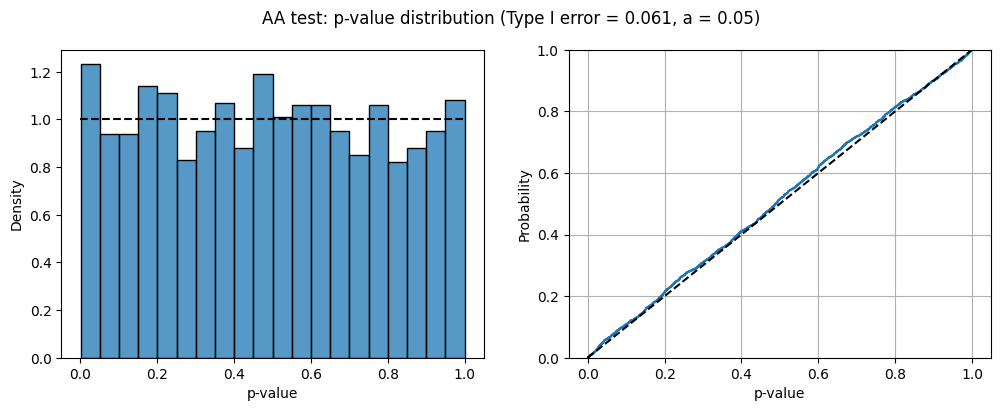

In [29]:
# AA simulation: no treatment effect

p_values = []

for _ in tqdm(range(n_simulations)):
    
    # Random split into control and treatment groups
    np.random.shuffle(user_ids)
    half = len(user_ids) // 2
    control_ids = user_ids[:half]
    treatment_ids = user_ids[half:]
    
    a_group_exp = df_simulation[df_simulation.CustomerID.isin(control_ids)]['cost_pre'].values
    b_group_exp = df_simulation[df_simulation.CustomerID.isin(treatment_ids)]['cost_pre'].values

    a_group_cov = df_simulation[df_simulation.CustomerID.isin(control_ids)]['cost_prepre'].values
    b_group_cov = df_simulation[df_simulation.CustomerID.isin(treatment_ids)]['cost_prepre'].values
    
    # Apply CUPED and run t-test
    a_cuped = get_cuped(a_group_cov, a_group_exp, theta, mu_prepre)
    b_cuped = get_cuped(b_group_cov, b_group_exp, theta, mu_prepre)
    
    _, p_val = stats.ttest_ind(a_cuped, b_cuped, equal_var=False)
    p_values.append(p_val)
    
# Empirical Type I error rate
type_1_error = np.mean(np.array(p_values) < alpha)

plot_pvalue_ecdf(p_values, f'AA test: p-value distribution (Type I error = {type_1_error:.3f}, a = {alpha})')
print(
    f'Available users in simulation window: {user_ids.size}\n'
    f'Required users by design: {cuped_n}'
)

## AB simulation (stat power) 

Validate statistical power under target effect.

100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:05<00:00, 388.42it/s]


Available users in simulation window: 1715
Required users by design: 1381


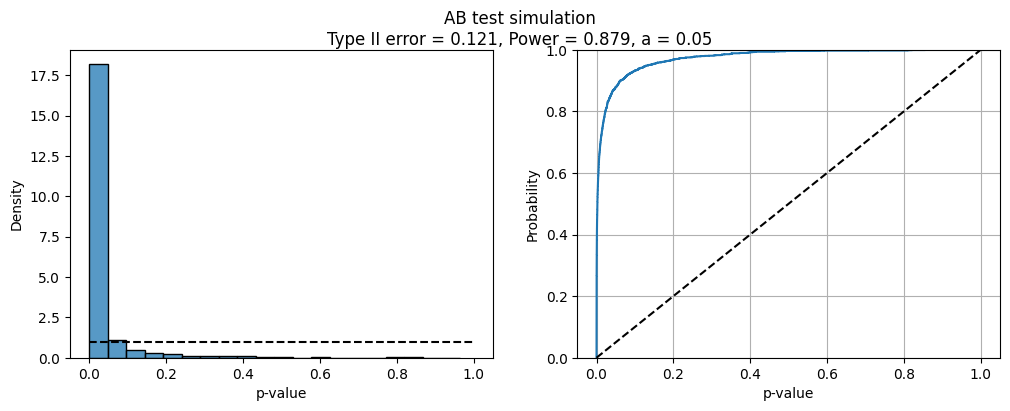

In [30]:
# AB simulation: inject a treatment effect equal to the target MDE

p_values_cuped = []
p_values_raw = []

for _ in tqdm(range(n_simulations)):
    
    # Random split into control and treatment groups
    np.random.shuffle(user_ids)
    half = len(user_ids) // 2
    control_ids = user_ids[:half]
    treatment_ids = user_ids[half:]
    
    a_group_exp = df_simulation[df_simulation.CustomerID.isin(control_ids)]['cost_pre'].values
    b_group_exp = df_simulation[df_simulation.CustomerID.isin(treatment_ids)]['cost_pre'].values
    b_group_exp = b_group_exp * (1 + mde_business_pct)    # inject treatment effect
    
    a_group_cov = df_simulation[df_simulation.CustomerID.isin(control_ids)]['cost_prepre'].values
    b_group_cov = df_simulation[df_simulation.CustomerID.isin(treatment_ids)]['cost_prepre'].values

    a_cuped = get_cuped(a_group_cov, a_group_exp, theta, mu_prepre)
    b_cuped = get_cuped(b_group_cov, b_group_exp, theta, mu_prepre)
    
    _, p_val = stats.ttest_ind(a_cuped, b_cuped, equal_var=False)
    p_values_cuped.append(p_val)
    
    _, p_val = stats.ttest_ind(a_group_exp, b_group_exp, equal_var=False)
    p_values_raw.append(p_val)

# Cuped Empirical Type II error and power    
type_2_error_cuped = np.mean(np.array(p_values_cuped) > alpha)
power_cuped = 1 - type_2_error_cuped

# Raw Empirical Type II error and power
type_2_error_raw = np.mean(np.array(p_values_raw) > alpha)
power_raw = 1 - type_2_error_raw


plot_pvalue_ecdf(
    p_values_cuped,
    title=f'AB test simulation\nType II error = {type_2_error_cuped:.3f}, Power = {power_cuped:.3f}, a = {alpha}'
)

print(
    f'Available users in simulation window: {user_ids.size}\n'
    f'Required users by design: {cuped_n}'
)

## Power comparison visualization

Compare ECDF of p-values for CUPED vs raw metric.

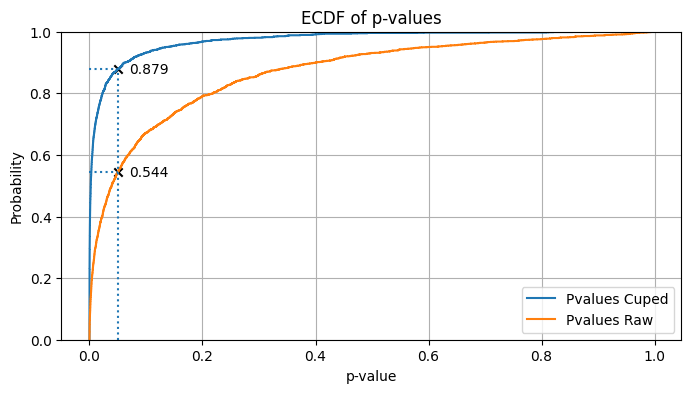

In [31]:
plt.figure(figsize=(8, 4))

sns.ecdfplot(p_values_cuped, label='Pvalues Cuped')
sns.ecdfplot(p_values_raw, label='Pvalues Raw')

plt.scatter([alpha, alpha], [power_cuped, power_raw], marker='x', color='black')

plt.axvline(alpha, ymin=0, ymax=power_cuped, linestyle=':')
plt.hlines(power_cuped, xmin=0, xmax=alpha, linestyles=':')
plt.hlines(power_raw, xmin=0, xmax=alpha, linestyles=':')

plt.text(alpha + 0.02, power_cuped, f'{power_cuped:.3f}', va='center')
plt.text(alpha + 0.02, power_raw, f'{power_raw:.3f}', va='center')

plt.xlabel('p-value')
plt.ylabel('Probability')
plt.title('ECDF of p-values')
plt.grid()
plt.legend()

plt.show()

The design has been validated in terms of sample size, duration, Type I error, and statistical power.

The setup is production-ready.